In [2]:
#importing libraries
import yfinance as yf
import pandas as pd
from datetime import datetime, timedelta
import numpy as np
from scipy.optimize import minimize

In [14]:
#defining tickers

tickers = ["IVV", "TLT", "IWM", "GLD", "XLF"]

In [ ]:
#end date and start date(7 years ago)

end_date = datetime.today()
start_date = end_date - timedelta(days = 7*365)
print(start_date)

Download Adjusted Close Prices

In [16]:
#empty DataFrame

adj_close_df = pd.DataFrame()

In [ ]:
#downloading close prices for tickers
for ticker in tickers:
    data = yf.download(ticker, start = start_date, end = end_date)
    adj_close_df[ticker] = data['Close']

In [ ]:
print(adj_close_df)

Generating Lognormal returns(additive)

In [20]:
log_returns = np.log(adj_close_df/adj_close_df.shift(1))

log_returns = log_returns.dropna() #drop any missing value

In [ ]:
#calculating covariance matrix

cov_matrix = log_returns.cov()*252
print(cov_matrix)

#PORTFOLIO PERFORMANCE METRICS

In [25]:
#standard deviation
def standard_deviation(weights, cov_matrix):
    variance = weights.T @ cov_matrix @ weights
    return np.sqrt(variance)

In [26]:
#expected returns
def expected_return(weights, log_returns):
    return np.sum(log_returns.mean()*weights)*252

In [27]:
#sharpe ratio
def sharpe_ratio(weights, log_returns, cov_matrix, risk_free_rate):
    return (expected_return(weights, log_returns) - risk_free_rate) / standard_deviation(weights, cov_matrix)

#PORTFOLIO OPTMISIATION

In [28]:
#setting the risk free rate(2%)
risk_free_rate = 0.02

In [31]:
from fredapi import Fred
fred = Fred(api_key = '33e9fa92f9156c49be51b968c2a2ca22')
ten_year_treasury_rate = fred.get_series_latest_release('GS10') / 100

risk_free_rate = ten_year_treasury_rate.iloc[-1]
print(risk_free_rate)

0.0426


In [32]:
#negative sharpe ratio
def neg_sharpe_ratio(weights, log_returns, cov_matrix, risk_free_rate):
    return -sharpe_ratio(weights, log_returns, cov_matrix, risk_free_rate)

In [33]:
#constraints and bounds

constraints = {'type': 'eq', 'fun': lambda weights: np.sum(weights) - 1}
bounds = [(0, 0.4) for _ in range(len(tickers))]

In [34]:
#initial weights
initial_weights = np.array([1/len(tickers)]*len(tickers))

In [36]:
#optimise weights to maximize sharpe  ratio

optimized_results = minimize(neg_sharpe_ratio, initial_weights, args=(log_returns, cov_matrix, risk_free_rate), method='SLSQP', constraints=constraints, bounds=bounds)
optimal_weights = optimized_results.x

ANALYSE THE OPTIMAL PORTFOLIO

In [37]:
print("Optimal Weights:")
for ticker, weight in zip(tickers, optimal_weights):
    print(f"{ticker}: {weight:.4f}")

optimal_portfolio_return = expected_return(optimal_weights, log_returns)
optimal_portfolio_volatility = standard_deviation(optimal_weights, cov_matrix)
optimal_sharpe_ratio = sharpe_ratio(optimal_weights, log_returns, cov_matrix, risk_free_rate)

print(f"Expected Annual Return: {optimal_portfolio_return:.4f}")
print(f"Expected Volatility: {optimal_portfolio_volatility:.4f}")
print(f"Sharpe Ratio: {optimal_sharpe_ratio:.4f}")

Optimal Weights:
IVV: 0.4000
TLT: 0.0205
IWM: 0.0000
GLD: 0.4000
XLF: 0.1795
Expected Annual Return: 0.1322
Expected Volatility: 0.1386
Sharpe Ratio: 0.6463


DISPLAY THE FINAL PORTFOLIO

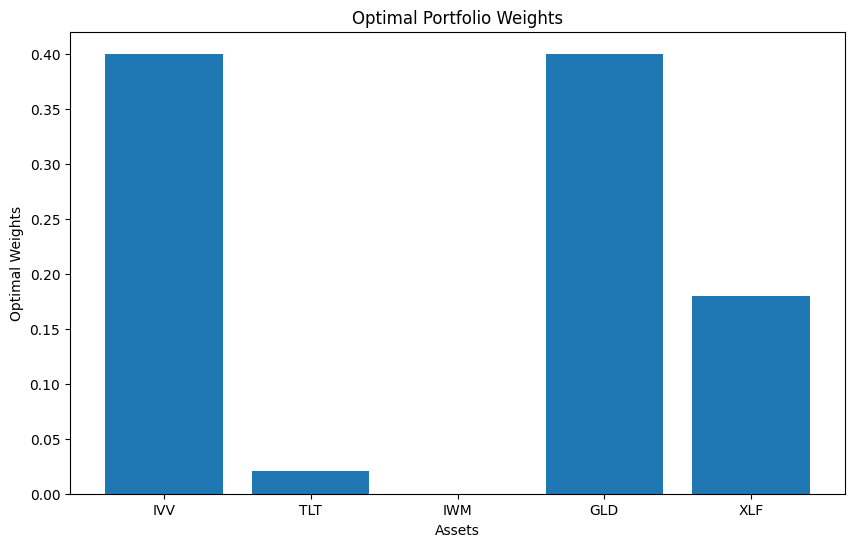

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(tickers, optimal_weights)

plt.xlabel('Assets')
plt.ylabel('Optimal Weights')
plt.title('Optimal Portfolio Weights')

plt.show()